<a href="https://colab.research.google.com/github/anderson-perez/IAC/blob/main/Introdu%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

## Ementa

* Fundamentos de Inteligência artificial.
* Representação do conhecimento.
* Métodos para resolução de problemas.
* *Aprendizado de máquina: classificação e reconhecimento de padrões.*
* *Deep learning.*
* *Redes Neurais Artificiais Estáticas e Dinâmicas.*
* *Desenvolvimento de sistemas inteligentes.*

# Bibliotecas que Serão Utilizadas ao Longo das Aulas

* scikit-learn
* Pandas
* Matplotlib
* Seaborn
* Yellowbrick
* TensorFlow
* Pytorch
* Gymnasium
* Stablebaselines3

# Introdução

Aprendizado de máquina é uma sub-área da Inteligência Artificial que visa treinar modelos para encontrar relações entre dados. Se dividem nas seguintes categorias:

* **Aprendizado supervisionado**
* **Aprendizado não supervisionado**
* **Aprendizado por reforço**
* **Inteligência Artificial Generativa**

# Aprendizado Supervisionado

O aprendizado supervisionado é uma área da Inteligência Artificial em que modelos são treinados a partir de dados rotulados, ou seja, cada exemplo de entrada está associado a uma saída conhecida. Divide-se em classificação, onde o modelo deve prever qual a classe que os dados pertencem, e regressão, onde o modelo deve prever um valor numérico contínuo.

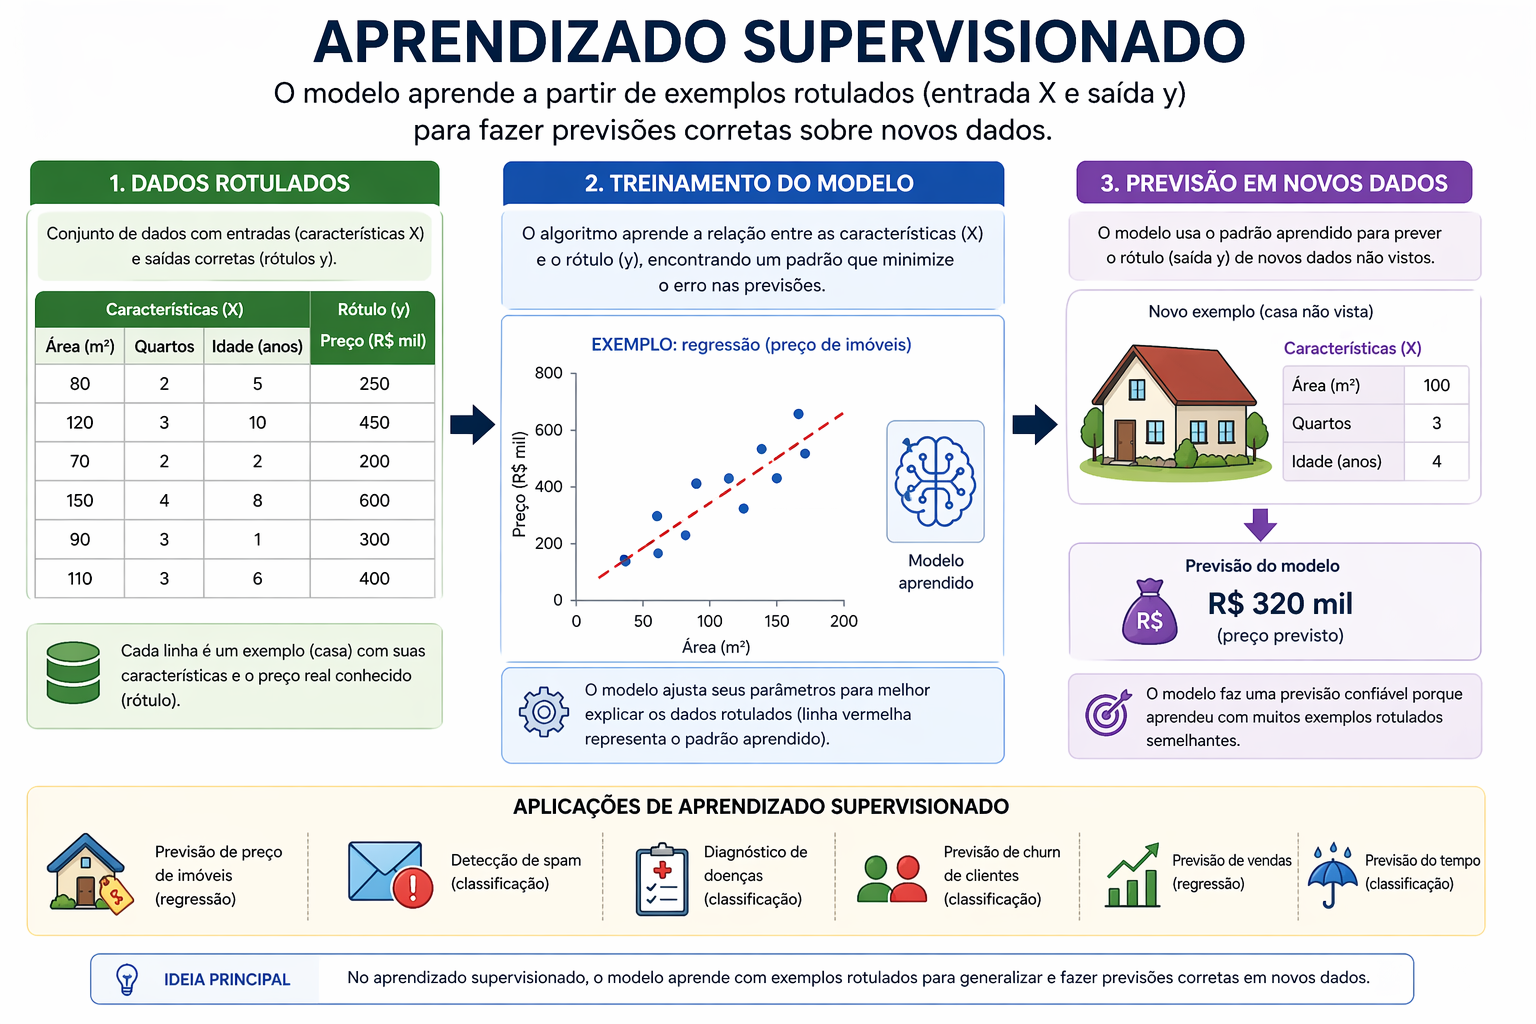

## As bibliotecas utilizadas nas aulas de Aprendizado Supervisionado serão:

* scikit-learn (https://scikit-learn.org/stable/)
* Algoritmos: Regressão Linear, Regressão Logística, Árvores de Decisão, KNN, Support Vector Machine (SVM) e Florestas Aleatórias.

## Exemplo Classificação (dados gerados aleatoriamente) - algoritmo KNN

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Gerar dados
X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.5, random_state=42)

# Criar modelo KNN
k = 3
knn = KNeighborsClassifier(n_neighbors=k)

# Treinar
knn.fit(X, y)

# Plotagem dos dados
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.title("Dados gerados com make_blobs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
# Criar grade de pontos
h = 0.1
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Prever para cada ponto da grade
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotagem da fronteira de decisão
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')

plt.title(f"KNN (k={k}) - Fronteira de decisão")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Aprendizado não Supervisionado

O aprendizao não supervisionado busca encontrar padrões, estruturas ou relações ocultas nos dados, como agrupamentos (clustering), redução de dimensionalidade e detecção de anomalias.

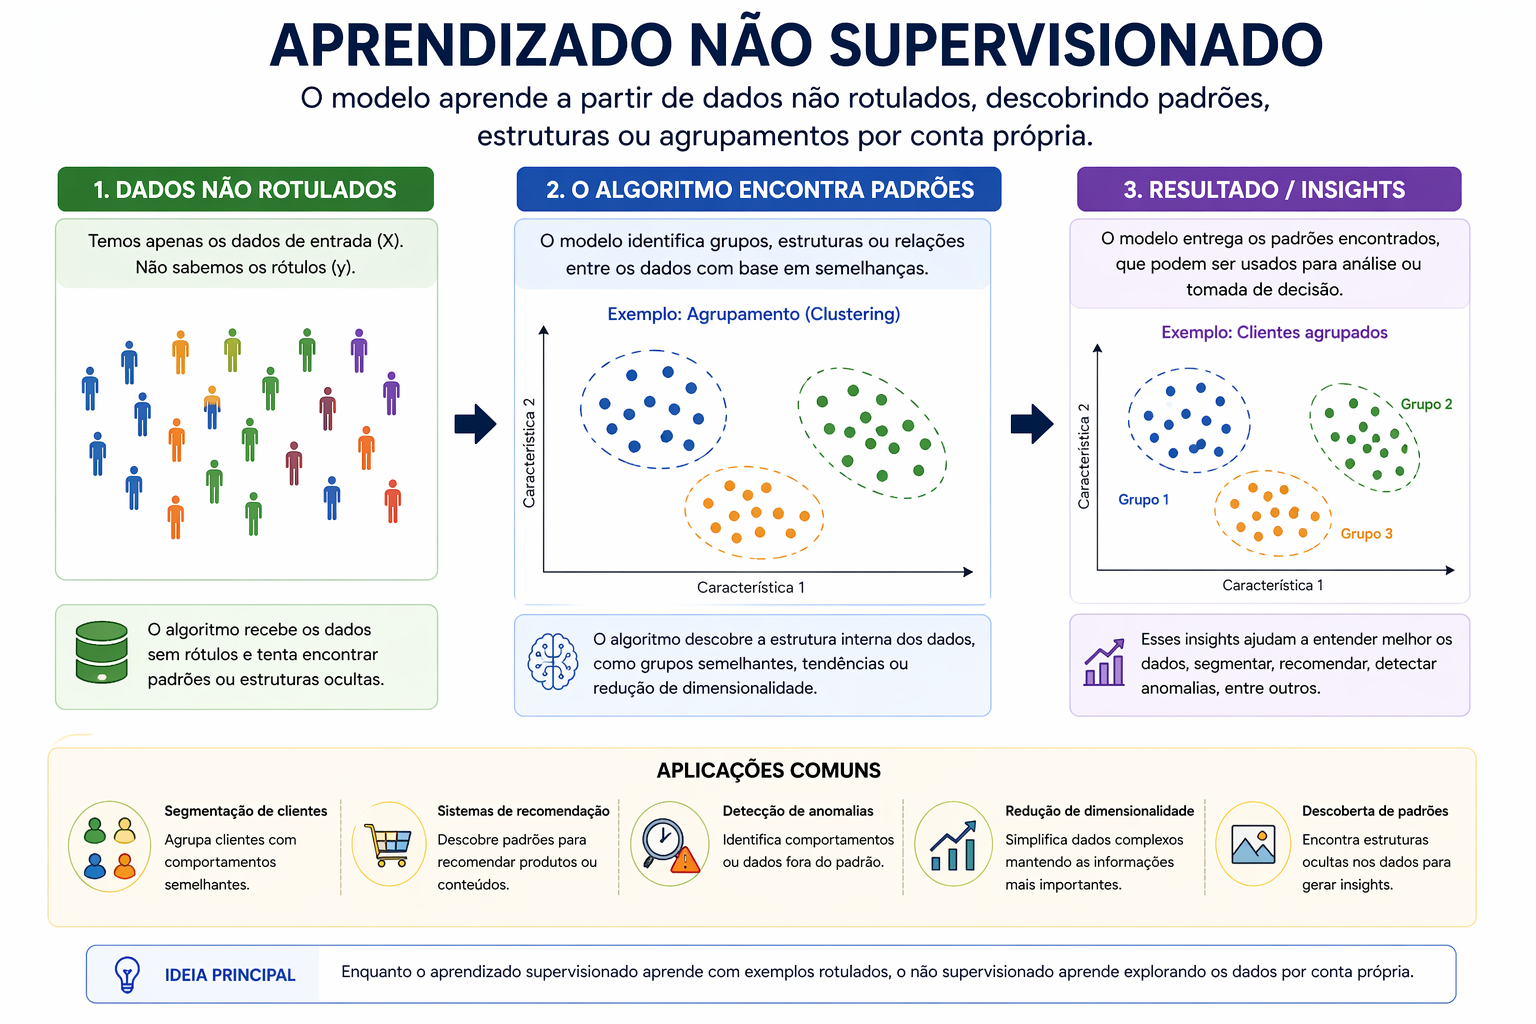

## As bibliotecas utilizadas nas aulas de Aprendizado não Supervisionado serão:

* scikit-learn (https://scikit-learn.org/stable/)
* Algoritmos: DBSCAN e K-Means

## Exemplo de Aprendizado não Supervisionado - algoritmo KMeans

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Gerar dados artificiais
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.5,
    random_state=42
)

# Criar o modelo KMeans
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Ajustar o modelo aos dados / treinamento
kmeans.fit(X)

# Obter os rótulos dos clusters e os centróides
labels = kmeans.labels_
centroides = kmeans.cluster_centers_

# Plotar os dados agrupados
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolor='k')
plt.scatter(
    centroides[:, 0],
    centroides[:, 1],
    s=300,
    marker='X',
    c='red',
    label='Centróides'
)

plt.title("K-Means com dados gerados por make_blobs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# Aprendizado por Reforço

No aprendizado por reforço um agente toma decisões em um ambiente. Cada ação tomada modifica o ambiente e gera uma recompensa. O objetivo do agente é maximizar as recompensas recebidas.

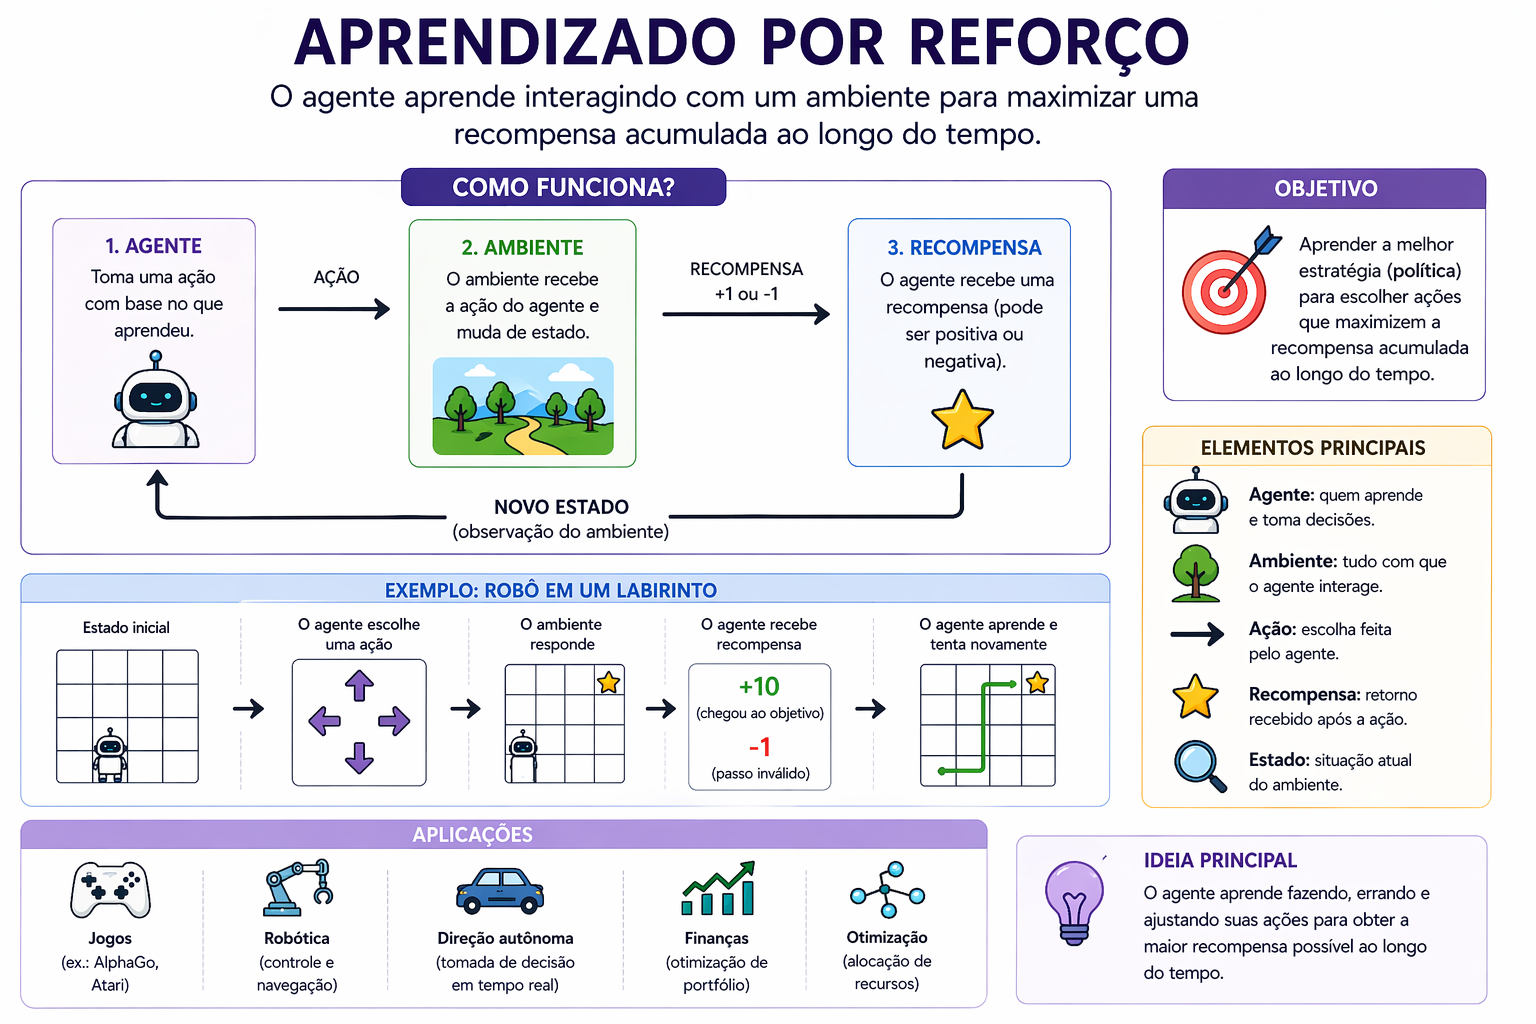

## As bibliotecas utilizadas nas aulas de Aprendizado por Reforço serão:

* Gymnasium (https://gymnasium.farama.org/)
* Stablebaselines3 (https://stable-baselines3.readthedocs.io/en/master/#)


## Exemplo de Aprendizado por Reforço

In [ ]:
import numpy as np
import gymnasium as gym
import random
from IPython.display import clear_output
import time


env = gym.make("Taxi-v3", render_mode="ansi")

env.reset()

env.render()

env.step(0)
env.render()

In [ ]:
# Tabela Q
q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Parâmetros do algoritmo
alfa = 0.1
gama = 0.6
epsilon = 0.1

# Executa por uma quantidade de episódios
for i in range(1, 10000):
  estado, _ = env.reset()
  epocas, penalizacao, recompensa = 0, 0, 0
  concluido = False

  while not concluido:
    # Exploração -> ação aleatória
    if random.uniform(0 ,1) < epsilon:
      acao = env.action_space.sample()
    # Exploitation -> ação definida na tabela Q
    else:
      acao = np.argmax(q_table[estado])

    prox_estado, recompensa, concluido, _, informacoes = env.step(acao)

    q_antigo = q_table[estado, acao]
    prox_valor_max = np.max(q_table[prox_estado])

    q_novo = (1 - alfa) * q_antigo + alfa * (recompensa + gama * prox_valor_max)
    q_table[estado, acao] = q_novo

    if recompensa == -10:
      penalizacao += 1

    estado = prox_estado
    epocas += 1

  if i % 100 == 0:
    clear_output(wait=True)
    print(f"Episodio: {i}")

print(f"Treinamento concluido... epocas: {epocas}")

In [ ]:
# Teste do algoritmo após o treinamento para obter a tabela Q
total_penalidades = 0
episodios = 10
total_epocas = 0

for _ in range(episodios):
  estado, _ = env.reset()
  penalidades, recompensa, epocas = 0, 0, 0
  concluido = False

  while not concluido:
    acao = np.argmax(q_table[estado])
    print(f"Acao: {acao}")
    estado, recompensa, concluido, _, informacoes = env.step(acao)

    if recompensa == -10:
      penalidades += 1

    epocas += 1

    clear_output(wait=True)
    print(env.render())
    time.sleep(.1)

  total_penalidades =+ penalidades
  total_epocas += epocas

print(f"Penalidade total {total_penalidades} em {total_epocas} epocas.")

# Inteligência Artificial Generativa

A Inteligência Artificial generativa é uma área da IA voltada à criação de novos conteúdos a partir de padrões aprendidos em dados existentes. Os modelos generativos são capazes de produzir textos, imagens, áudio e até código, simulando características dos dados com os quais foram treinados

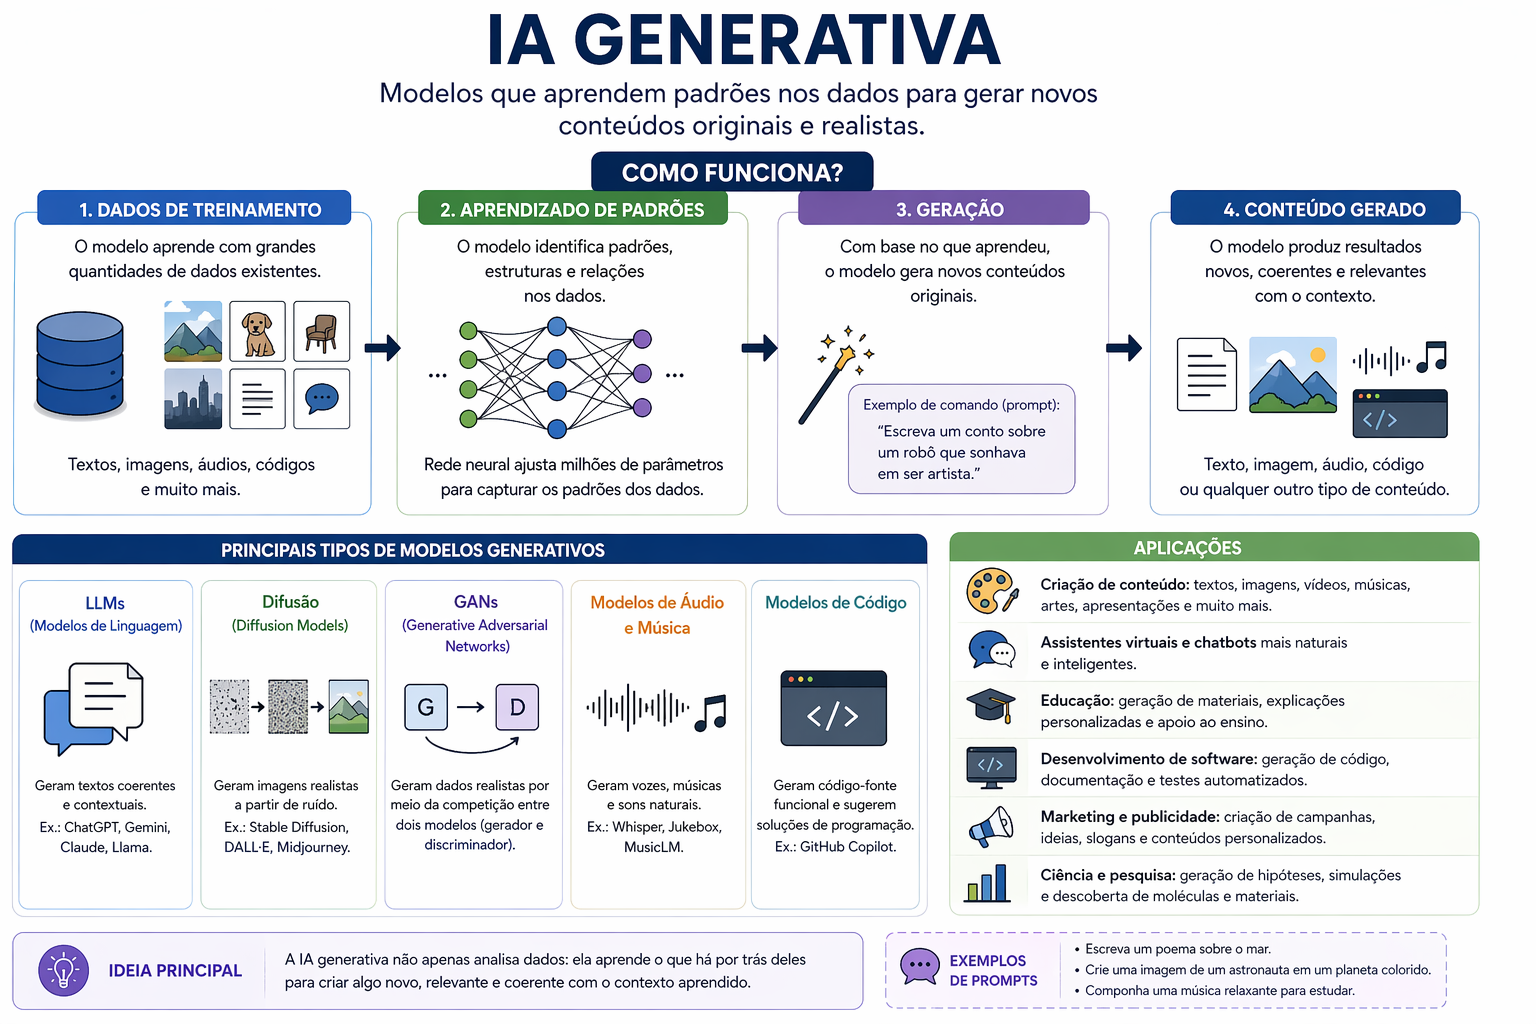

## As bibliotecas utilizadas nas aulas de IA generativa serão:

* TensorFlow (https://www.tensorflow.org/?hl=pt-br)
* Keras (https://keras.io/)
* Torch (https://pytorch.org/)


## Exemplo de IA Generativa - Redes GAN (Generative Adversial Network)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Reprodutibilidade
torch.manual_seed(42)

# =========================
# 1. Dados reais
# =========================
# Distribuição real: N(4, 1.25)
def real_data(batch_size):
    return torch.randn(batch_size, 1) * 1.25 + 4.0

# Ruído de entrada do gerador
def noise_data(batch_size, noise_dim):
    return torch.randn(batch_size, noise_dim)

# =========================
# 2. Gerador
# =========================
class Generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, z):
        return self.net(z)

# =========================
# 3. Discriminador
# =========================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# =========================
# 4. Inicialização
# =========================
noise_dim = 5
G = Generator(noise_dim)
D = Discriminator()

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.001)
opt_D = optim.Adam(D.parameters(), lr=0.001)

# =========================
# 5. Treinamento
# =========================
epochs = 3000
batch_size = 64

losses_G = []
losses_D = []

for epoch in range(epochs):
    # ---------------------
    # Treinar Discriminador
    # ---------------------
    D.zero_grad()

    # Dados reais
    x_real = real_data(batch_size)
    y_real = torch.ones(batch_size, 1)

    pred_real = D(x_real)
    loss_real = criterion(pred_real, y_real)

    # Dados falsos
    z = noise_data(batch_size, noise_dim)
    x_fake = G(z).detach()
    y_fake = torch.zeros(batch_size, 1)

    pred_fake = D(x_fake)
    loss_fake = criterion(pred_fake, y_fake)

    loss_D = loss_real + loss_fake
    loss_D.backward()
    opt_D.step()

    # ---------------------
    # Treinar Gerador
    # ---------------------
    G.zero_grad()

    z = noise_data(batch_size, noise_dim)
    x_fake = G(z)
    y_gen = torch.ones(batch_size, 1)

    pred = D(x_fake)
    loss_G = criterion(pred, y_gen)

    loss_G.backward()
    opt_G.step()

    losses_D.append(loss_D.item())
    losses_G.append(loss_G.item())


# =========================
# 6. Visualização
# =========================
# Amostras reais
x_real_plot = real_data(1000).detach().numpy()

# Amostras geradas
z = noise_data(1000, noise_dim)
x_fake_plot = G(z).detach().numpy()

plt.figure(figsize=(8, 5))
plt.hist(x_real_plot, bins=40, alpha=0.6, label="Dados reais")
plt.hist(x_fake_plot, bins=40, alpha=0.6, label="Dados gerados")
plt.title("GAN didática: distribuição real vs. gerada")
plt.xlabel("Valor")
plt.ylabel("Frequência")
plt.legend()
plt.show()

# Pipeline de IA

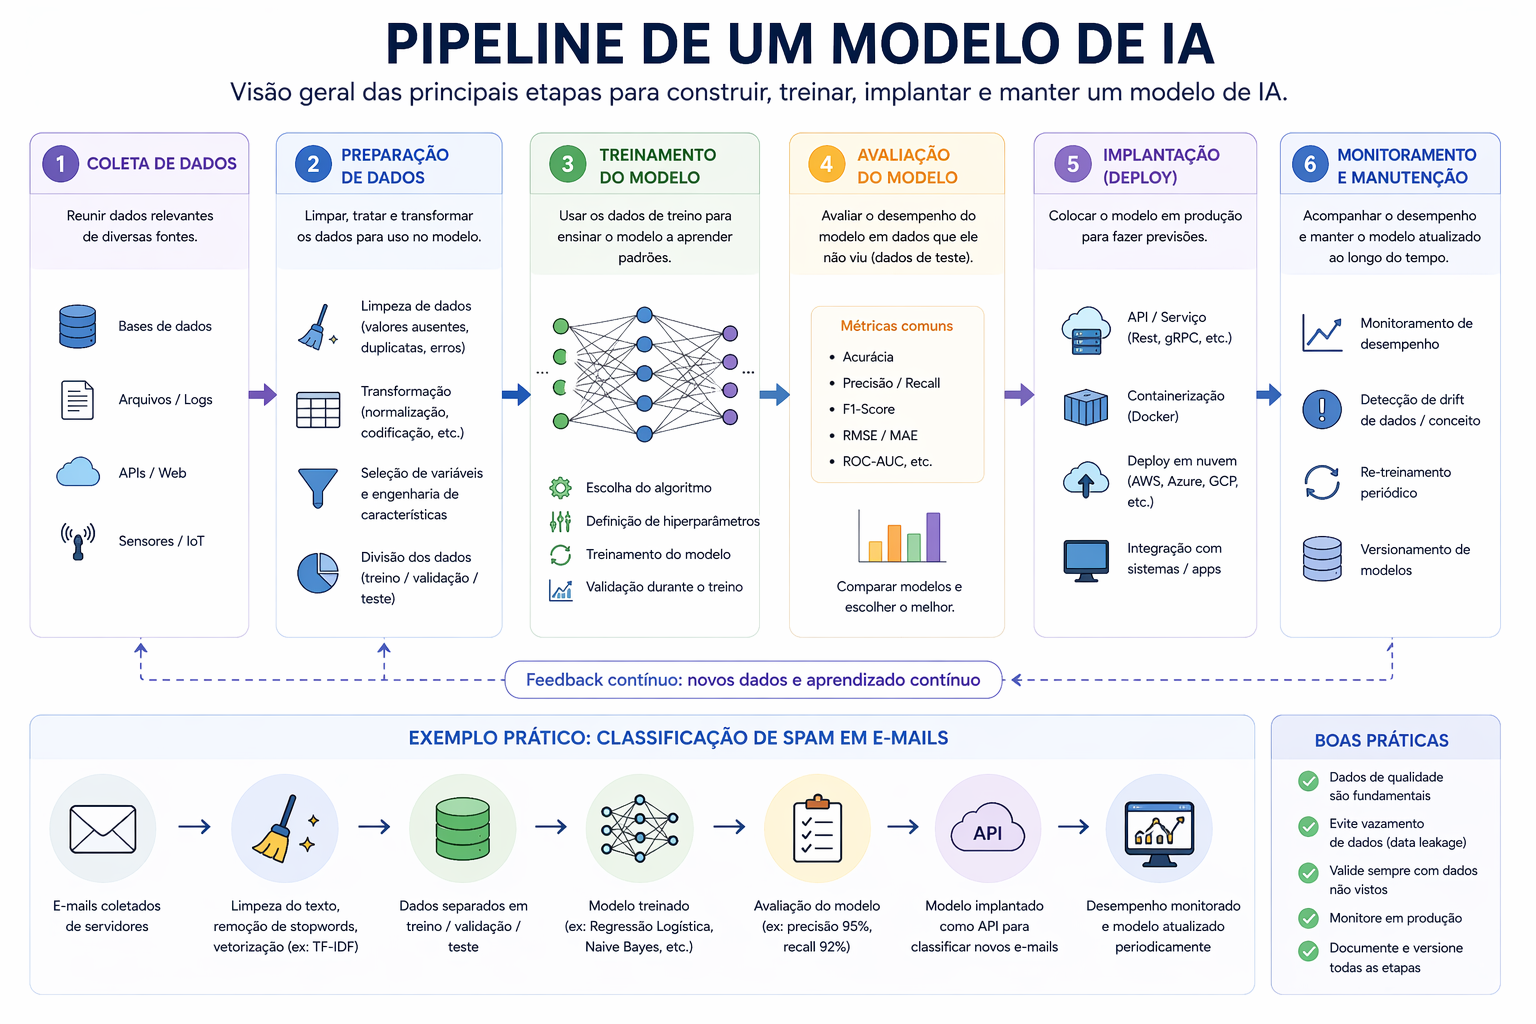

# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

# Créditos

* As imagens que ilustram os tipos de modelos foram geradas pelo chatgpt.